In [6]:

import matplotlib.pyplot as plt
import numpy as np

import torch


from torchvision import datasets, transforms


### Вычислительный граф
PyTorch строит граф вычислений для операций с тензорами, у которых `requires_grad=True`




In [14]:
a = torch.tensor([
    [3, 2, 1],
    [5, 2, 6],
    [7, 1, 4]
])

b = torch.tensor([
    [3, 2, 2],
    [99, 1, 6],
    [7, 5, 4]
])

print(a.shape, b.shape)

torch.Size([3, 3]) torch.Size([3, 3])


In [22]:
x = torch.arange(100)
print(x.shape)

x = x.view(10, -1)
print(x.shape)

x = torch.rand(256, 256, 3) # ! нельзя (256, 256, 3) -> (3, 256, 256)

print(x.shape)
x = x.permute(2, 0, 1)
print(x.shape)

torch.Size([100])
torch.Size([10, 10])
torch.Size([256, 256, 3])
torch.Size([3, 256, 256])


In [29]:
x = torch.randn(10, 10, requires_grad=True)
y = torch.randn(10, 10, requires_grad=True)

z = ((x + y)**2).sum()

print(z)
print(x.grad, y.grad)

z.backward()

print(x.grad, y.grad)


tensor(187.3732, grad_fn=<SumBackward0>)
None None
tensor([[ 2.8106,  3.1065,  2.7890, -3.2195, -4.2542, -3.3394,  1.8884,  1.7544,
          1.4514,  0.7182],
        [-3.4078, -4.5557, -3.7036, -0.5752, -1.9235, -2.4730,  0.4735,  1.3469,
         -2.8586,  0.1317],
        [-1.2935, -3.8447,  0.8575, -0.3578, -3.8763,  3.3894,  0.1740,  3.3331,
          0.2889, -6.4300],
        [ 3.3572,  2.0897,  1.0496, -2.5898,  0.9033, -2.9484, -0.0534,  1.0647,
          3.1396,  1.1563],
        [ 4.2695, -1.9597, -4.6491,  2.1115, -0.0203,  0.4743, -0.4855, -0.4457,
         -3.6792, -3.0827],
        [-0.6736,  4.0046, -0.6126, -1.3008,  0.1601, -1.2936,  0.9242,  2.9543,
         -0.0428, -0.6233],
        [-8.0470, -2.8800, -1.7881, -0.1279,  1.4320, -1.9343, -2.3212, -1.0127,
          0.7207, -0.8555],
        [-1.4584,  0.9628,  1.4864,  3.3840, -1.9150,  1.4143, -0.3107, -7.9484,
          1.5772, -4.2677],
        [ 1.2745, -3.8702,  5.6708, -2.6658, -4.1504,  1.0839,  1.5684, -1.94

## Загрузка и визуализация данных CIFAR-10

CIFAR-10
- **60,000 цветных изображений** размером 32x32 пикселя
- **10 классов** объектов
- **50,000 изображений** для обучения
- **10,000 изображений** для тестирования


In [5]:
# !pip install torch torchvision

(32, 32, 3) 6
(32, 32, 3) 9
(32, 32, 3) 9
(32, 32, 3) 4
(32, 32, 3) 1
(32, 32, 3) 1
(32, 32, 3) 2
(32, 32, 3) 7
(32, 32, 3) 8
(32, 32, 3) 3


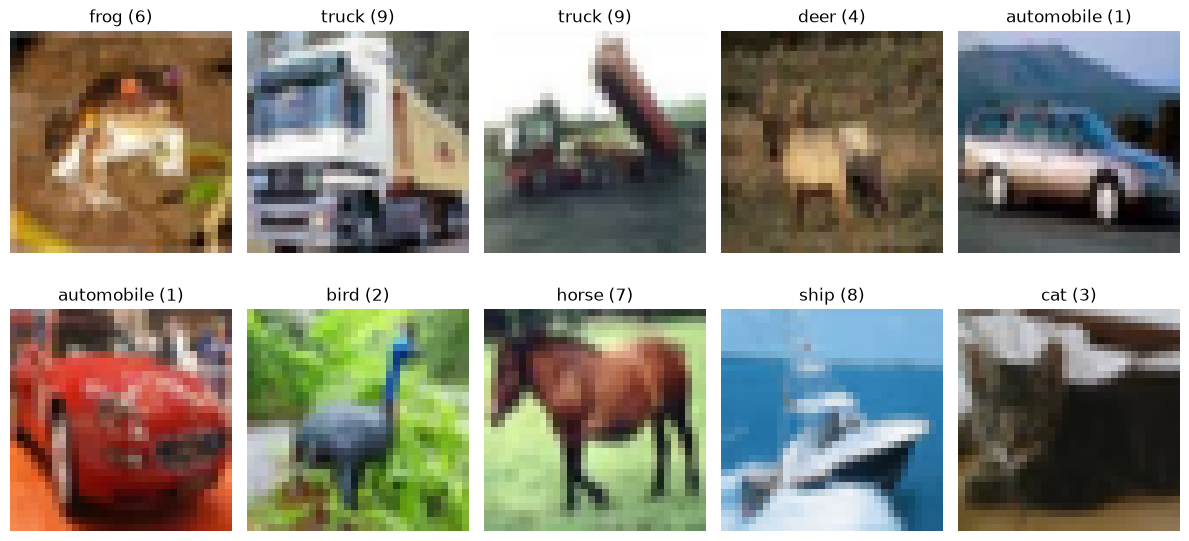

(32, 32, 3) 3
(32, 32, 3) 8
(32, 32, 3) 8
(32, 32, 3) 0
(32, 32, 3) 6
(32, 32, 3) 6
(32, 32, 3) 1
(32, 32, 3) 6
(32, 32, 3) 3
(32, 32, 3) 1


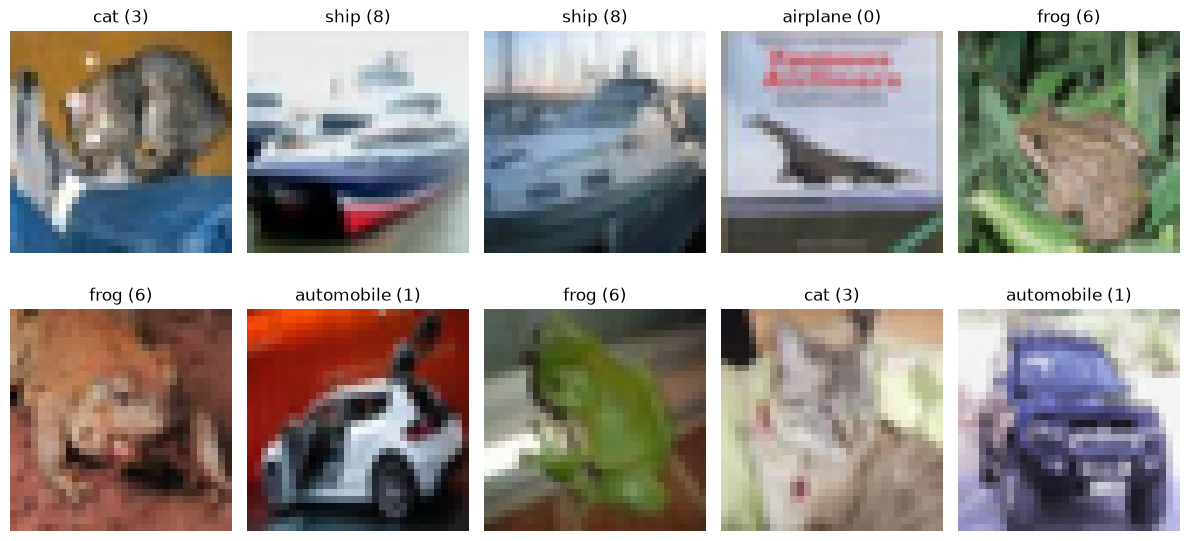

In [34]:
# Подгрузим данные для последующего обучения

from torchvision import datasets

train_dataset = datasets.CIFAR10('./data', train=True, download=True, transform=None)
test_dataset = datasets.CIFAR10('./data', train=False, download=True, transform=None)

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
           'dog', 'frog', 'horse', 'ship', 'truck']

def show_images(dataset, num_images=10):
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    axes = axes.ravel()
    
    for i in range(num_images):
        image, label = dataset[i]
        print(np.array(image).shape, label)
        
        axes[i].imshow(image)
        axes[i].set_title(f'{classes[label]} ({label})')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()


show_images(train_dataset)

show_images(test_dataset)

In [36]:
print("Размер обучающего датасета:", len(train_dataset))
print("Размер тетового датасета:", len(test_dataset))


Размер обучающего датасета: 50000
Размер тетового датасета: 10000


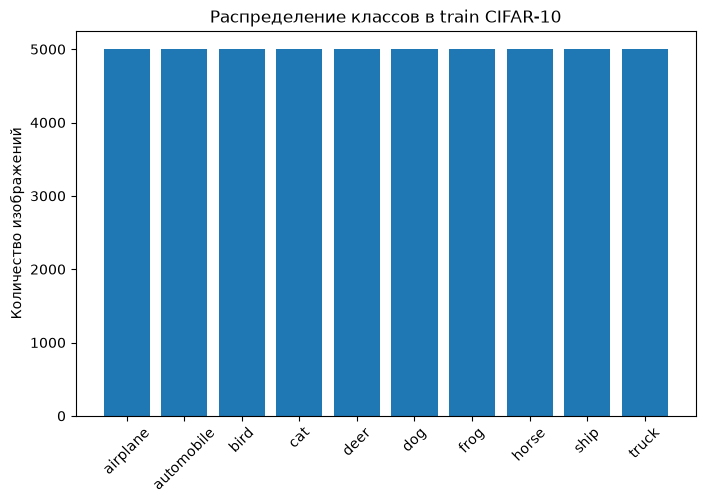

In [37]:
from collections import Counter

train_labels = [label for _, label in train_dataset]
class_counts = Counter(train_labels)

plt.figure(figsize=(8,5))
plt.bar(classes, [class_counts[i] for i in range(10)])
plt.title("Распределение классов в train CIFAR-10")
plt.xticks(rotation=45)
plt.ylabel("Количество изображений")
plt.show()


## Создание модели

In [39]:
from torchvision import datasets
import matplotlib.pyplot as plt
import numpy as np

train_dataset = datasets.CIFAR10('./data', train=True, download=True, transform=None)

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
           'dog', 'frog', 'horse', 'ship', 'truck']

print(len(classes))

print(len(train_dataset))
print(train_dataset[1])

image_test = train_dataset[0][0]


10
50000
(<PIL.Image.Image image mode=RGB size=32x32 at 0x11F4AD280>, 9)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.4567447..3.955073].


tensor([[0.0823, 0.1202, 0.0718, 0.0854, 0.1331, 0.1728, 0.1109, 0.0523, 0.0881,
         0.0832],
        [0.0818, 0.1210, 0.0704, 0.0857, 0.1322, 0.1725, 0.1107, 0.0524, 0.0884,
         0.0848],
        [0.0851, 0.1223, 0.0699, 0.0849, 0.1308, 0.1736, 0.1087, 0.0517, 0.0881,
         0.0851],
        [0.0837, 0.1233, 0.0705, 0.0863, 0.1313, 0.1743, 0.1092, 0.0505, 0.0870,
         0.0838],
        [0.0820, 0.1220, 0.0708, 0.0867, 0.1302, 0.1731, 0.1102, 0.0523, 0.0875,
         0.0850],
        [0.0831, 0.1237, 0.0699, 0.0861, 0.1304, 0.1715, 0.1107, 0.0517, 0.0879,
         0.0850],
        [0.0856, 0.1228, 0.0703, 0.0846, 0.1308, 0.1737, 0.1084, 0.0516, 0.0872,
         0.0850],
        [0.0844, 0.1231, 0.0706, 0.0850, 0.1295, 0.1719, 0.1114, 0.0513, 0.0872,
         0.0857],
        [0.0837, 0.1214, 0.0714, 0.0850, 0.1317, 0.1689, 0.1107, 0.0527, 0.0898,
         0.0849],
        [0.0823, 0.1231, 0.0703, 0.0867, 0.1295, 0.1738, 0.1088, 0.0521, 0.0880,
         0.0853],
        [0

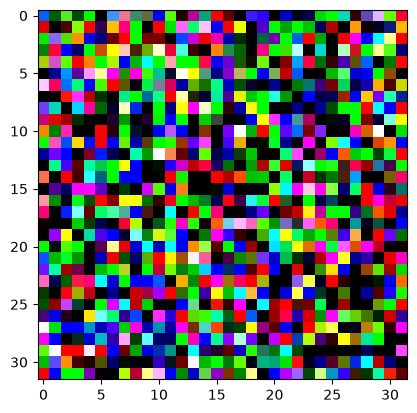

In [ ]:
from torch import nn

from torch.optim import Adam
# (B, 3, 256, 256)
# (1, 32*32*3) -> -> 32

class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear_1 = nn.Linear(32*32*3, 16)
        self.relu = nn.ReLU()
        self.linear_2 = nn.Linear(16, 32)
        self.linear_3 = nn.Linear(32, 10)
        self.softmax = nn.Softmax()

    def forward(self, x):
        # (B, 32*32*3)
        x = x.view(x.size(0), -1)

        x = self.linear_1(x)
        x = self.relu(x) # функция активацию

        x = self.linear_2(x)
        x = self.relu(x) # функция активацию
        # эмбединги, 
 
        x = self.linear_3(x) # логиты
        
        x = self.sigmoid(x)

        return x


# Создание модели

model = MLP()

test_image = torch.randn(64, 32, 32, 3)

plt.imshow(test_image[0, :, :, :])

print(model(test_image))


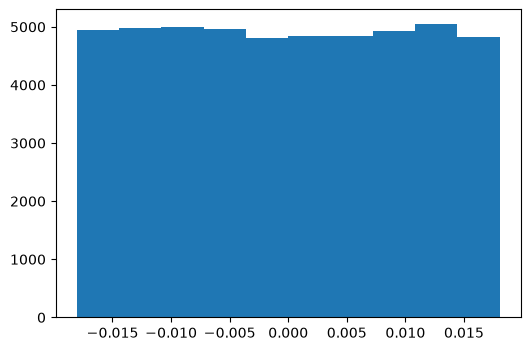

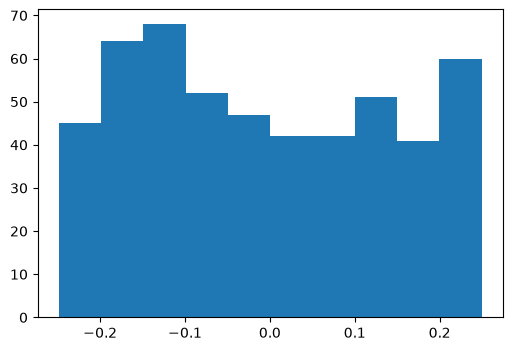

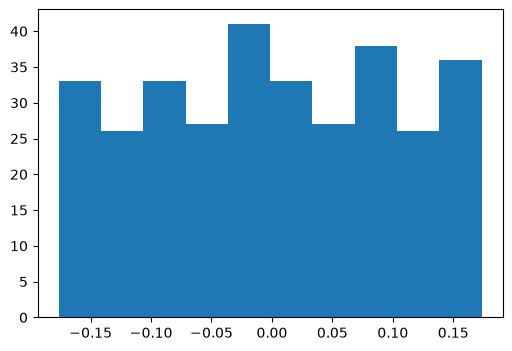

In [55]:
# можно посмотреть распределение весов по слоям

import matplotlib.pyplot as plt

for name, param in model.named_parameters():
    if "weight" in name:
        plt.figure(figsize=(6,4))
        plt.hist(param.detach().numpy().flatten())
        plt.show()


In [58]:
!pip install tqdm


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
# Цикл обучения

from torchvision import datasets, transforms
from tqdm import tqdm

transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10('./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False)


model = MLP()

criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

epochs = 5
train_losses = []

# 50000/64

for epoch in range(epochs):
    running_loss = 0.0
    
    for images, labels in tqdm(train_loader):

        predict = model(images)
        # 
        
        
        
    print(f'loss: {sum(train_losses)/ len(train_losses)}')
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {sum(train_losses)/ len(train_losses)}')


 12%|█▏        | 95/782 [00:00<00:00, 946.04it/s]

torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([6

 36%|███▌      | 283/782 [00:00<00:00, 834.60it/s]

torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([6

 60%|█████▉    | 469/782 [00:00<00:00, 888.69it/s]

...

 83%|████████▎ | 650/782 [00:00<00:00, 890.00it/s]

torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([6

100%|██████████| 782/782 [00:00<00:00, 888.70it/s]

torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([64, 10])
torch.Size([6

ZeroDivisionError: division by zero

In [ ]:

model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        print(labels)

    print(f'Accuracy: {100 * correct / total}%')

# Инициализация весов нейросетей

При обучении нейронных сетей очень важно, **как заданы начальные значения весов**.  

Если выбрать их неправильно:
- Сеть может **не учиться** (например, если все веса одинаковые → нет различий между нейронами)  
- Обучение может быть **очень медленным** (слишком маленькие веса → сигналы затухают)  
- Может возникнуть эффект **взрыва градиентов** (слишком большие веса → активации и градиенты растут без контроля)  


## Основные стратегии инициализации

1. **Constant** — все веса одинаковые  
   демонстрация того, что сеть перестаёт обучаться  

2. **Низкая дисперсия** (например, `Normal(0, 0.01)`)  
   сеть учится очень медленно, сигналы почти исчезают  

3. **Высокая дисперсия** (например, `Normal(0, 1)`)  
   сеть нестабильна, градиенты взрываются  

4. **Xavier (Glorot)**  
   - подбирает дисперсию весов так, чтобы сигналы сохраняли масштаб при прохождении через слои  
   - хорошо работает для `tanh` и `sigmoid`  

5. **He (Kaiming)**  
   - модификация Xavier под `ReLU`  
   - учитывает, что часть нейронов обнуляется  
   - формула дисперсии:  



In [ ]:

import torch.nn.init as init

class NetworkMLP(nn.Module):
    def __init__(self, num_inputs, num_hidden, num_outputs, act_fn=nn.Sigmoid()):
        super().__init__()
        self.linear1 = nn.Linear(num_inputs, num_hidden)
        self.act_fn = act_fn
        self.linear2 = nn.Linear(num_hidden, num_outputs)

    def forward(self, x):
        z1 = self.linear1(x)
        a1 = self.act_fn(z1)
        z2 = self.linear2(a1)
        return z1, a1, z2

In [ ]:
def initialize_weights(model, mode="xavier"):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            if mode == "constant":
                init.constant_(m.weight, 0.01)
            elif mode == "low_var":
                init.normal_(m.weight, mean=0.0, std=0.01)
            elif mode == "high_var":
                init.normal_(m.weight, mean=0.0, std=1.0)
            elif mode == "xavier":
                init.xavier_uniform_(m.weight)
            elif mode == "he":
                init.kaiming_uniform_(m.weight, nonlinearity="relu")
            if m.bias is not None:
                init.constant_(m.bias, 0)


def plot_layer_distributions(model, title):
    """Распределения весов по слоям"""
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))
    layers = [model.linear1, model.linear2]

    for i, layer in enumerate(layers):
        weights = layer.weight.detach().cpu().numpy().flatten()
        axs[i].hist(weights, bins=50)
        axs[i].set_title(f"{title} | Layer {i+1}\nmean={weights.mean():.4f}, std={weights.std():.4f}")

    plt.tight_layout()
    plt.show()

def plot_activation_distributions(model, mode):
    """Распределения активаций"""
    x = torch.randn(128, 3*32*32)
    with torch.no_grad():
        z1, a1, z2 = model(x)

    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    for i, (data, name) in enumerate([(z1, "z1 pre-activation"),
                                      (a1, "a1 post-activation"),
                                      (z2, "z2 output")]):
        arr = data.cpu().numpy().flatten()
        axs[i].hist(arr, bins=50)
        axs[i].set_title(f"{mode} | {name}\nmean={arr.mean():.4f}, std={arr.std():.4f}")
    plt.tight_layout()
    plt.show()

In [ ]:
modes = ["constant", "low_var", "high_var", "xavier", "he"]

for mode in modes:
    print(f"\n=== {mode.upper()} INITIALIZATION ===")
    model = NetworkMLP(3*32*32, 100, 10, act_fn=nn.Tanh())
    initialize_weights(model, mode=mode)

    # Веса по слоям
    plot_layer_distributions(model, mode)

    # Активации
    plot_activation_distributions(model, mode)

# Сверточная нейронная сеть


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
           'dog', 'frog', 'horse', 'ship', 'truck']

In [ ]:
import torch.nn.functional as F


class ConvNet(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return x
    
model = ConvNet()

In [ ]:
# Цикл обучения
from torchvision import datasets, transforms
from tqdm import tqdm

transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10('./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
# test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False)


model = ConvNet()

criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

epochs = 5
train_losses = []

for epoch in range(epochs):
    running_loss = 0.0
    
    for images, labels in tqdm(train_loader):
        # считаем лосс и обновляем градиенты

        print(f'loss: {sum(train_losses)/ len(train_losses)}')

    print(f'Epoch [{epoch+1}/{epochs}], Loss: {sum(train_losses)/ len(train_losses)}')


In [ ]:

model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f'Accuracy: {100 * correct / total}%')

В PyTorch **нет отдельной функции** с названием `global_avg_pool2d`.  

Вместо этого используют **адаптивное усреднение**, которое позволяет задать любой размер выходного тензора:  

- Функция: `torch.nn.functional.adaptive_avg_pool2d`  
- Слой: `nn.AdaptiveAvgPool2d`  

Если задать `output_size=1`, то результат соответствует **Global Average Pooling** по всем пространственным координатам.


In [ ]:
# Модель с global avg pooling

import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvNetGAP(nn.Module):
    def __init__(self):
        super().__init__()


    def forward(self, x):

        return x

model = ConvNetGAP()

